데이터 전처리 및 요약

1. 결측치 확인 

- 채널정보 : 'OS구분코드'에 유일하게 결측치 존재(전체 행의 약 20% 정도, 27,2261개)
- 승인매출정보(310-406) : 결측치가 존재하지 않았음. 

2. 고윳값이 1인 변수 확인 
* 전체 행에 값이 오로지 1개만 존재하는 행은 모두 제외하였음.
* 고윳값이 1인 피쳐는 상관계수를 돌릴때 결측치로 나오게됨을 알게되었음.

- 채널정보
"인입횟수_금융_IB_R6M", "인입불만횟수_IB_R6M", "인입불만일수_IB_R6M", "인입불만월수_IB_R6M", "인입불만후경과월_IB_R6M",
"인입불만횟수_IB_B0M", "인입불만일수_IB_B0M", "IB문의건수_한도_B0M", "IB문의건수_결제_B0M", "IB문의건수_할부_B0M",
"IB문의건수_정보변경_B0M", "IB문의건수_결제일변경_B0M", "IB문의건수_명세서_B0M", "IB문의건수_비밀번호_B0M", "IB문의건수_SMS_B0M",
"IB문의건수_APP_B0M", "IB문의건수_부대서비스_B0M", "IB문의건수_포인트_B0M", "IB문의건수_BL_B0M", "IB문의건수_분실도난_B0M",
"IB문의건수_CA_B0M", "IB상담건수_VOC_B0M", "IB상담건수_VOC민원_B0M", "IB상담건수_VOC불만_B0M", "IB상담건수_금감원_B0M",
"IB문의건수_명세서_R6M", "IB문의건수_APP_R6M", "IB상담건수_VOC_R6M", "IB상담건수_VOC민원_R6M", "IB상담건수_VOC불만_R6M",
"IB상담건수_금감원_R6M", "불만제기건수_B0M", "불만제기건수_R12M", "당사PAY_방문횟수_B0M", "당사PAY_방문횟수_R6M",
"당사PAY_방문월수_R6M"

- 승인매출정보(310-406)
"이용금액_당사페이_R6M", "이용금액_당사기타_R6M", "이용건수_당사페이_R6M", "이용건수_당사기타_R6M", "이용금액_당사페이_R3M",
"이용금액_당사기타_R3M", "이용건수_당사페이_R3M", "이용건수_당사기타_R3M", "이용금액_당사페이_B0M", "이용금액_당사기타_B0M",
"이용건수_당사페이_B0M", "이용건수_당사기타_B0M", "승인거절건수_입력오류_B0M", "승인거절건수_기타_B0M"

상관분석을 기반으로한 Feature Selection

1. 채널정보
- 문자형 변수들이 Segment와 어떤 관련이 있는지를 검토하기 위해 크레머V(두 범주형 변수 간의 통계적 독립 여부를 검정하는 방법)을 사용하였다. 상관계수는 수치형 변수 간의 관계만 측정할 수 있기 때문에, 문자형 변수와의 연관성 측정에는 적절하지 않기 때문이다. 결과로는 문자형 6개의 컬럼 모두 유의미한 결과가 나왔다.

- p-value가 적다는 것은, 해당 변수와 Segment가 완전히 독립적이지 않다는 의미로 해석될 수 있다. 즉, 시스템(앱, 모바일, PC 등)에 따라 고객 세그멘트가 구분될 수 있다는 것이다.

- 방문횟수_앱_R6M, 방문횟수_PC_R6M은 값이 높게 나타났는데, 이는 Segment별로 방문 패턴 차이가 존재함을 의미함. OS구분코드는 유의미는 하지만, 그 영향력은 상대적으로 약하다.

- 또한 범주형 변수인 Segment와 수치형 변수들과의 비교를 위해서 ETA제곱값(설명력)을 사용. 

- 에타제곱을 사용한 칼럼들은 0.14, 크레머V를 사용한 컬럼들은 0.1을 기준으로 가져옴.

- 그 결과, 1번 파일부터 8번파일까지 총 76개의 피쳐가 선택되었음.

MODEL1 : PCA 

- 본인은 n_components 15개로 PCA를 통한 차원축소 작업을 진행하였음


- 15개의 주성분과 그 구성피쳐들은 다음과 같다.

-📌 주성분 p1
이용금액_일시불_R12M    0.653985
청구금액_R6M         0.412379
이용금액_오프라인_R6M    0.307691
이용금액_일시불_R6M     0.269442
이용금액_R3M_신용체크    0.204094
Name: p1, dtype: float64

📌 주성분 p2
청구금액_R6M         0.768977
이용금액_일시불_R12M    0.482542
청구금액_R3M         0.340864
이용금액_일시불_R6M     0.114128
청구금액_B0          0.104889
Name: p2, dtype: float64

📌 주성분 p3
이용금액_오프라인_R6M    0.571257
이용금액_일시불_R12M    0.502397
이용금액_R3M_신용체크    0.341948
이용금액_오프라인_R3M    0.275814
이용금액_R3M_신용      0.269260
Name: p3, dtype: float64

📌 주성분 p4
이용금액_오프라인_R6M      0.637384
이용금액_R3M_신용체크      0.484040
이용금액_R3M_신용        0.348635
_2순위카드이용금액         0.250438
최대이용금액_일시불_R12M    0.163003
Name: p4, dtype: float64

📌 주성분 p5
잔액_일시불_B1M      0.434325
잔액_일시불_B2M      0.421026
월중평잔_일시불_B0M    0.360463
평잔_일시불_3M       0.353694
월중평잔_일시불        0.350086
Name: p5, dtype: float64

📌 주성분 p6
이용금액_일시불_R6M     0.625635
이용금액_R3M_신용체크    0.357718
이용금액_일시불_R3M     0.296299
_2순위카드이용금액       0.292886
이용금액_오프라인_R6M    0.256983
Name: p6, dtype: float64

📌 주성분 p7
최대이용금액_일시불_R12M    0.843843
청구금액_R3M           0.243497
이용금액_일시불_R12M      0.219971
이용금액_일시불_R6M       0.202921
이용금액_R3M_신용체크      0.172475
Name: p7, dtype: float64

📌 주성분 p8
청구금액_R3M           0.654416
최대이용금액_일시불_R12M    0.390400
이용금액_일시불_R6M       0.363688
청구금액_R6M           0.342813
청구금액_B0            0.240860
Name: p8, dtype: float64

📌 주성분 p9
_1순위업종_이용금액      0.632792
_2순위카드이용금액       0.402607
청구금액_R3M         0.299092
_1순위쇼핑업종_이용금액    0.288148
_1순위카드이용금액       0.285301
Name: p9, dtype: float64

📌 주성분 p10
이용금액_R3M_신용체크    0.555430
이용금액_R3M_신용      0.458517
_2순위카드이용금액       0.447764
_1순위업종_이용금액      0.422845
_1순위쇼핑업종_이용금액    0.196210
Name: p10, dtype: float64

📌 주성분 p11
이용금액_오프라인_R3M    0.624870
정상입금원금_B5M       0.284151
정상입금원금_B2M       0.272861
연체입금원금_B5M       0.264638
연체입금원금_B2M       0.252730
Name: p11, dtype: float64

📌 주성분 p12
이용금액_오프라인_R3M    0.548352
정상입금원금_B5M       0.368195
연체입금원금_B5M       0.315929
연체입금원금_B2M       0.282841
정상입금원금_B0M       0.258668
Name: p12, dtype: float64

📌 주성분 p13
정상청구원금_B5M    0.542158
정상입금원금_B5M    0.402333
정상청구원금_B2M    0.339734
정상청구원금_B0M    0.333962
청구금액_R3M      0.246588
Name: p13, dtype: float64

📌 주성분 p14
_1순위카드이용금액       0.594485
이용금액_R3M_신용      0.405358
이용금액_오프라인_R3M    0.324700
_1순위업종_이용금액      0.301935
_2순위카드이용금액       0.288990
Name: p14, dtype: float64

📌 주성분 p15
잔액_일시불_B2M      0.625290
월중평잔_일시불        0.413588
청구금액_B0         0.374287
평잔_일시불_3M       0.348877
월중평잔_일시불_B0M    0.205540
Name: p15, dtype: float64

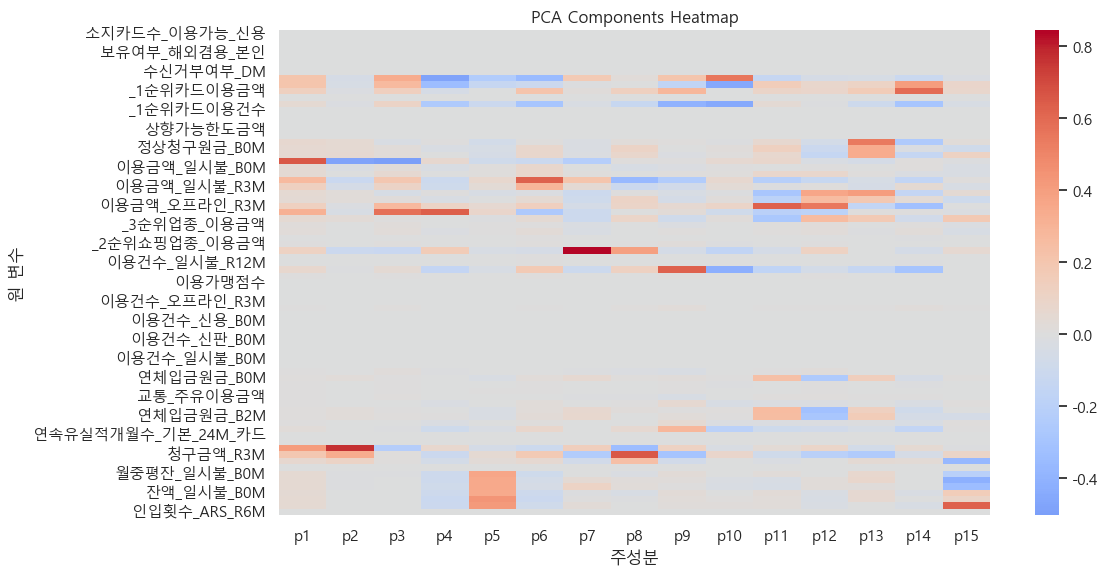


- 히트맵에 대한 분석

🔍 주요 주성분별 해석
📌 p1: 일시불 위주의 장기 소비 규모
대표 변수: 이용금액_일시불_R12M, 청구금액_R6M, 오프라인 소비

👉 일시불 중심의 소비 규모가 큰 고객군을 대표.

장기적 카드 사용량과 실제 청구액의 연관성 강조

📌 p2: 최근 청구 중심 소비 패턴
청구금액_R6M, 일시불_R12M, 청구금액_R3M

👉 청구액이 최근 3~6개월 간 증가한 사용자

단기적 지출 급증 여부 파악 가능

📌 p3: 오프라인 소비 집중 + 체크카드 사용
오프라인_R6M, 일시불_R12M, R3M_신용체크

👉 체크카드 및 오프라인 사용 비중이 높은 고객

온라인보다 실물거래 선호 소비자층

📌 p4: 단기·중기 오프라인 + 다카드 사용자
오프라인_R6M, 신용체크, _2순위카드이용금액

👉 여러 카드 사용하는 중·단기 소비자

📌 p5: 잔액 및 평균 보유금액 중심 소비
잔액_일시불_B1M~B2M, 월중평잔, 평잔_일시불

👉 잔액 유지 성향이 강한 고객군

리볼빙 또는 연체 대비 여유자금 파악 가능

📌 p6: 일시불 단기 소비 + 다카드 보유자
일시불_R6M, R3M_신용체크, _2순위카드

👉 체크카드 사용 + 단기 일시불 사용량 큰 고객

📌 p7: 최대 이용액 기반 소비 집중도
최대이용금액_일시불, 청구금액_R3M

👉 한 번에 크게 소비하는 집중형 소비자군

하이리스크·하이스팬딩 가능성 있음

📌 p8: 청구금액 비중 높은 단기 소비자
청구금액_R3M, 일시불_R6M, 청구금액_B0

👉 최근 결제비율이 높은 고객층

📌 p9: 주요 업종 기반 소비 성향
_1순위업종_이용금액, _1순위쇼핑, _2순위카드

👉 특정 업종에서의 지출 집중도 파악 가능

📌 p10: 다카드 + 쇼핑 중심 사용자
신용체크, _2순위카드, _1순위쇼핑업종

👉 카드 다수 사용 + 특정 쇼핑군 집중

📌 p11~13: 정상/연체 입금 및 청구 흐름 중심
정상입금원금, 연체입금원금, 정상청구원금

👉 고객의 상환 상태나 리스크 상태 파악에 유용

신용도 분류 및 리스크 모델과 연결 가능

📌 p14: 오프라인+업종 중심 소비
_1순위카드, _1순위업종, 오프라인_R3M

👉 오프라인 위주 주요 업종 이용자

📌 p15: 잔액 중심 + 최근 청구 변동
잔액_일시불_B2M, 월중평잔, 청구금액_B0

👉 보유금 유지하면서 최근 청구액이 있는 고객

🧠 결론 요약
총 15개의 주성분을 통해, 고객의 소비 패턴을
✅ 장기 vs 단기,
✅ 일시불 vs 청구 중심,
✅ 온라인 vs 오프라인,
✅ 체크카드 vs 신용카드,
✅ 단일 vs 다카드 사용자
등의 다차원적인 축으로 해석 가능

- train 데이터의 XGBoost f1_score는 0.8971204166666666가 나왔음.

- 이후, 30개로 추가작업을 진행하였지만 15개로 했을때보다 하이퍼파라미터의 f1-score가 낮았음 (최적의 모델 평균 성능 : 0.8732666666666666)

- 혼동행렬 




MODEL2 : Feature Importance 

- 에타제곱과 크레머V로 잘라낸 76개의 컬럼으로 Feature Importance를 통해 모델을 만들어보았다. 
 

- Feature Importance는,
👉 모델이 예측할 때 어떤 변수에 얼마나 의존했는지를 수치로 보여주는 지표이다

- 값이 클수록 → 예측에 큰 영향을 준 변수

- 주로 트리 기반 모델에서 자동 계산됨 (ex. RandomForest, XGBoost)

- Importance가 높은 top_n = 20만 골랐다.

"정상청구원금_B5M", "이용금액_오프라인_B0M", "연속유실적개월수_기본_24M_카드", "이용금액_R3M_신용체크", "이용금액_R3M_신용", "이용금액대", "보유여부_해외겸용_본인", "연체입금원금_B5M", "이용건수_신용_R12M", "이용카드수_신용체크","이용금액_일시불_R12M", "이용건수_일시불_R6M", "상향가능한도금액", "정상청구원금_B0M", "최대이용금액_일시불_R12M","소지카드수_유효_신용", "상향가능CA한도금액", "정상청구원금_B2M", "이용금액_일시불_R6M", "이용카드수_신용"

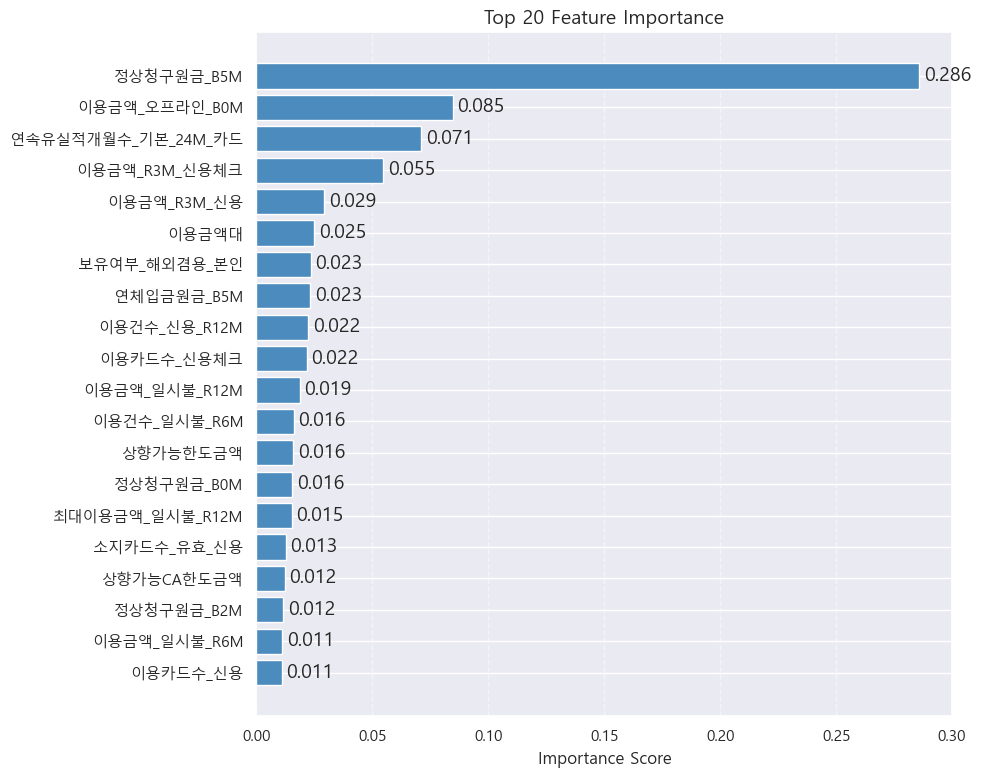

- XGBoost의 평균 f1 Score : 0.8902795833333335

- 데이콘 점수 : 0.5407로 최고점수를 기록 

- 혼동행렬 
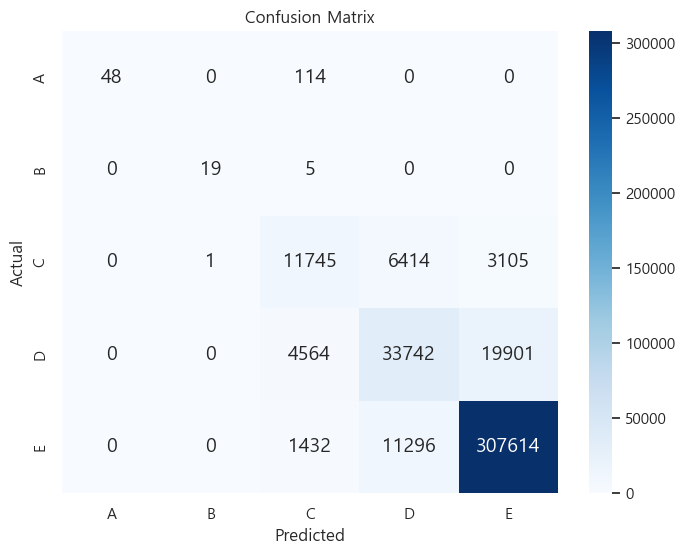

- 혼동행렬 해석

| 클래스 | 정답 수    | 대표 오예측 대상           | 비고                    |
| --- | ------- | ------------------- | --------------------- |
| A   | 48      | 114 (C로)            | 소수 클래스, 정답률 낮음        |
| B   | 19      | 5 (C로)              | 샘플 수 매우 적음            |
| C   | 11,745  | 6,414(D), 3,105(E)  | 절반 가까이 오예측            |
| D   | 33,742  | 4,564(C), 19,901(E) | **오예측 많음**, 경계 모호     |
| E   | 307,614 | 1,432(C), 11,296(D) | 정답률 높지만 일부 **D로 분산됨** |




MODEL3 : 파생변수 10개를 추가한 Feature Importance 


✅ 파생변수 생성 전략 요약 (76개 컬럼 기준)
📌 1. 카드 이용 관련 비율/평균
🔹 총 금액 / 건수 = 1건당 금액
train_df['신용_1건당이용금액'] = train_df['이용금액_R3M_신용'] / (train_df['이용건수_신용_R3M'] + 1e-5)

🔹 최근 3개월 vs 12개월 = 소비 집중도
train_df['소비집중도_신용'] = train_df['이용금액_일시불_R3M'] / (train_df['이용금액_일시불_R12M'] + 1e-5)

🔹 온라인 vs 오프라인 비율
train_df['온라인비중'] = train_df['이용금액_온라인_B0M'] / (
    train_df['이용금액_온라인_B0M'] + train_df['이용금액_오프라인_B0M'] + 1e-5)

📌 2. 업종별, 쇼핑별 총합
train_df['쇼핑업종총합'] = train_df['_1순위쇼핑업종_이용금액'] + train_df['_2순위쇼핑업종_이용금액'] + train_df['_3순위쇼핑업종_이용금액']
train_df['업종이용금액총합'] = train_df['_1순위업종_이용금액'] + train_df['_2순위업종_이용금액'] + train_df['_3순위업종_이용금액']


📌 3. 최근 시점 변화량 / 추이
예: 0M vs 2M (이번달 vs 두 달 전)
train_df['정상청구원금_증감'] = train_df['정상청구원금_B0M'] - train_df['정상청구원금_B2M']
train_df['일시불잔액_증감'] = train_df['잔액_일시불_B0M'] - train_df['잔액_일시불_B2M']


📌 4. 이용패턴 관련 조합
총 이용카드수 대비 이용가맹점수 → 다양성 지표
train_df['가맹점_카드당비율'] = train_df['이용가맹점수'] / (train_df['이용카드수_신용체크'] + 1e-5)

상향가능한도금액 vs 이용금액
train_df['한도대비이용'] = train_df['이용금액_R3M_신용체크'] / (train_df['상향가능한도금액'] + 1e-5)


📌 5. 이진 변수 묶기 (수신거부여부 등)
train_df['수신거부합계'] = train_df[['수신거부여부_TM', '수신거부여부_메일', '수신거부여부_DM']].sum(axis=1)


📌 6. 특이 행동 탐지
페이_온라인_B0M 유무 → 간편결제 여부
train_df['페이사용여부'] = (train_df['이용금액_페이_온라인_B0M'] > 0).astype(int)


- Top20 Feature 
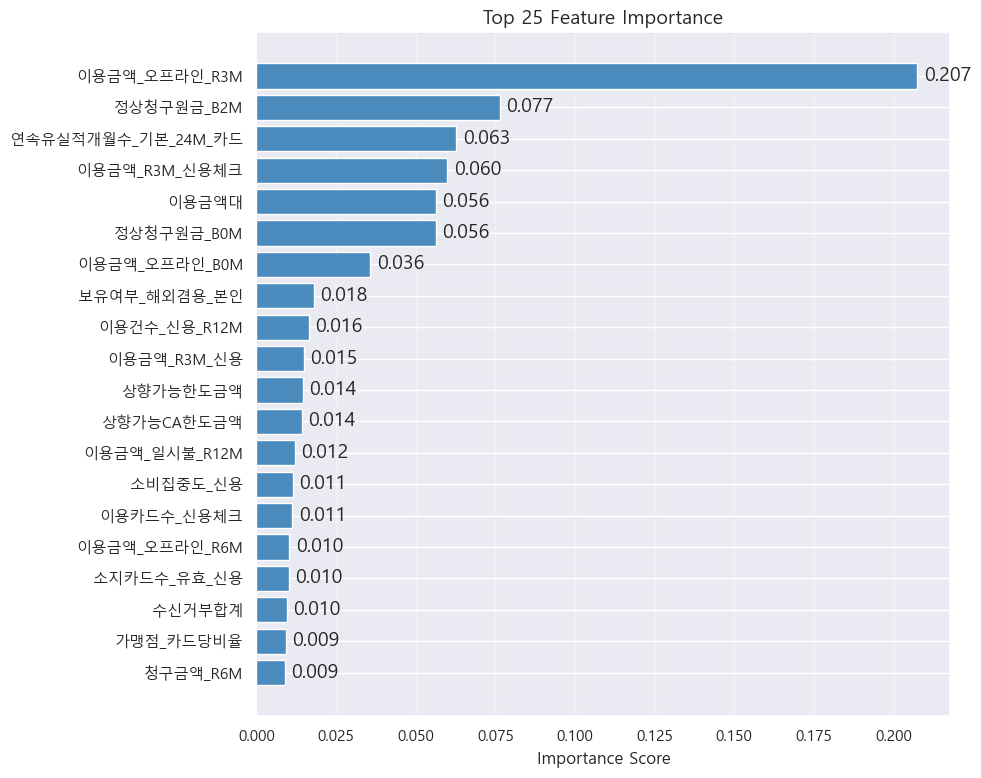

평균 f1 Score : 0.8846325

- 오히려 더 감소하는 모습을 보인다. 그 이유가 뭘까? 
- 혼동행렬을 그려보고 원인 분석해보기 

MODEL4 VIF

- 다중공산성이 지나치게 큰 칼럼들을 모두 삭제하였다. 

 "이용건수_신판_R6M",
"이용건수_신판_R3M",
    "이용건수_신용_R6M",
    "이용건수_신판_R12M",
    "이용건수_신용_R3M",
    "이용건수_신용_R12M",
    "이용건수_신판_B0M",
    "이용건수_일시불_R3M",
    "이용건수_신용_B0M",
    "이용건수_일시불_R6M",
    "이용건수_일시불_B0M",
    "이용건수_일시불_R12M",

- 시계열 칼럼처럼 비슷한 칼럼들끼리는 미리 구해놨던 에타제곱을 기준으로 보고 지워나가는 작업을 수행하였다. 

"정상청구원금_B2M",
    "정상청구원금_B0M",
    "정상입금원금_B2M",
    "이용금액_일시불_B0M",
    "이용금액_일시불_R6M",
    "이용금액_일시불_R3M",
    "연체입금원금_B2M",
    "연체입금원금_B5M",
    "잔액_일시불_B1M",
    "잔액_일시불_B2M"

하지만, VIF를 하게되면 다중공산성이 높어 삭제한 칼럼들 중 모델 성능에 중요한 영향을 미치는 피쳐들까지 삭제되어버리는 상황이 발생하여 예측도가 떨어지는 모습이 나타났다.

MODEL5 : 방법1을 적용한 모델

[방법1]

- train 데이터를 학습용과 검증용으로 나눈다.
- 학습용 데이터를 C,D,E 그룹과 A,B 그룹으로 나눈다.
- 각 그룹의 데이터를 각각 학습을 시킨다(모델이 서로 달라도 된다)
- 검증용데이터를 나누지 않고 각 모델을 통해 예측 확률을 구한다.
- C,D,E를 학습한 모델에 대해 예측 확률을 구한다.
- A,B를 학습한 모델에 대해 예측 확율을 구한다.
- C,D,E를 학습한 모델의 확률 결과에서 원래 결과가 C 인 것은 C가 매우 높게 나오는지, D 인것은 D 가 매우 높게 나오는지 E 인것은 E가 매우 높게 나오는지 그리고 A와 B는 C, D, E일 확율이 0.5와 가까운지
- A,B를 확습한 모델의 확률 결과에서 원래 결과가 A 인 것은 A가 매우 높게 나오는지, B 인것은 B가 매우 높게 나오는지 그리고 C, D, E인 것은 A와 B일 확률이 0.5와 가까운지
-검증용 데이터를 전체를 각각의 모델에 넣어서 각각 예측을 한다.
- A,B를 예측한 결과중 A 또는 B일 확률이 높은 결과를 C,D,E를 예측한 결과에 덮어씌운다.
- 최종적으로 합친 결과 데이터를 진짜 결과와 비교하여 평가를 진행한다.
- 예측할 데이터를 위와 같은 방법으로 예측하여 합친 결과를 최종 결과로 결정한다.

1. 모델 AB

- 사용한 피쳐
  '이용후경과월_할부_무이자', '이용후경과월_할부', '이용개월수_할부_무이자_R12M',
       '이용개월수_할부_R12M', '카드이용한도금액_B2M', '카드이용한도금액_B1M', '카드이용한도금액',
       '이용개월수_할부_R6M', 'CA한도금액', '이용개월수_할부_무이자_R6M', '이용개월수_할부_R3M',
       '이용개월수_할부_무이자_R3M', '이용건수_할부_무이자_R3M', '이용건수_할부_R3M', '이용금액_할부_무이자_R6M',
       '방문횟수_앱_R6M', '거주시도명', 'RV전환가능여부', '연령', 'Life_Stage', '인입횟수_ARS_R6M',
       '캠페인접촉건수_R12M', '이용메뉴건수_ARS_R6M', '대표청구서수령지구분코드', '청구서수령방법',
       '캠페인접촉일수_R12M', '방문일수_PC_R6M', '방문횟수_PC_R6M', '할인건수_R3M'

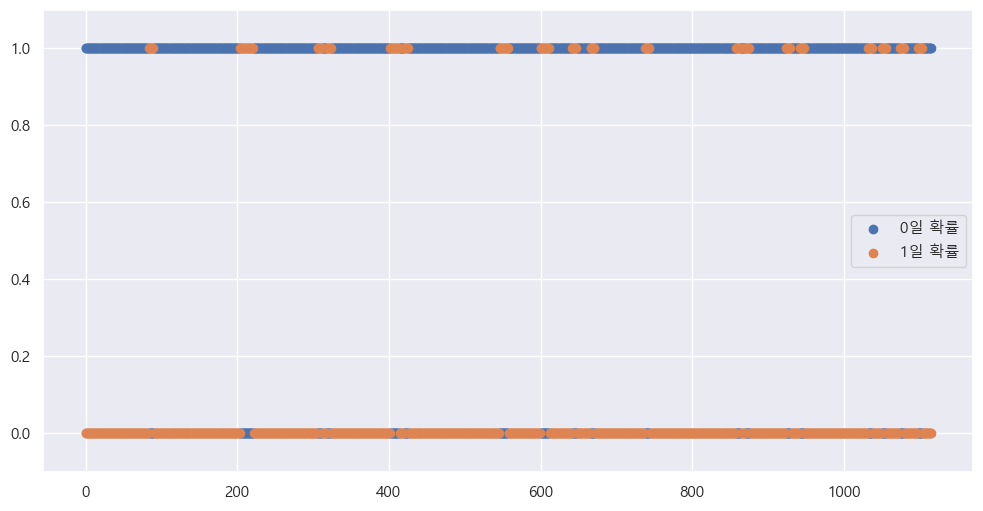
-BEST모델: LGBM하이퍼튜닝모델

2. 모델 CDE

- 사용한피쳐
- '방문횟수_앱_R6M', '인입횟수_ARS_R6M', '방문일수_PC_R6M',
       '방문횟수_PC_R6M', '이용금액대', '이용금액_R3M_신용체크', '청구금액_R6M', '이용금액_R3M_신용',
       '청구금액_R3M', '청구금액_B0', '_1순위카드이용금액', '이용카드수_신용체크', '_2순위카드이용금액',
       '_1순위카드이용건수', '_2순위카드이용건수', '이용카드수_신용'

- 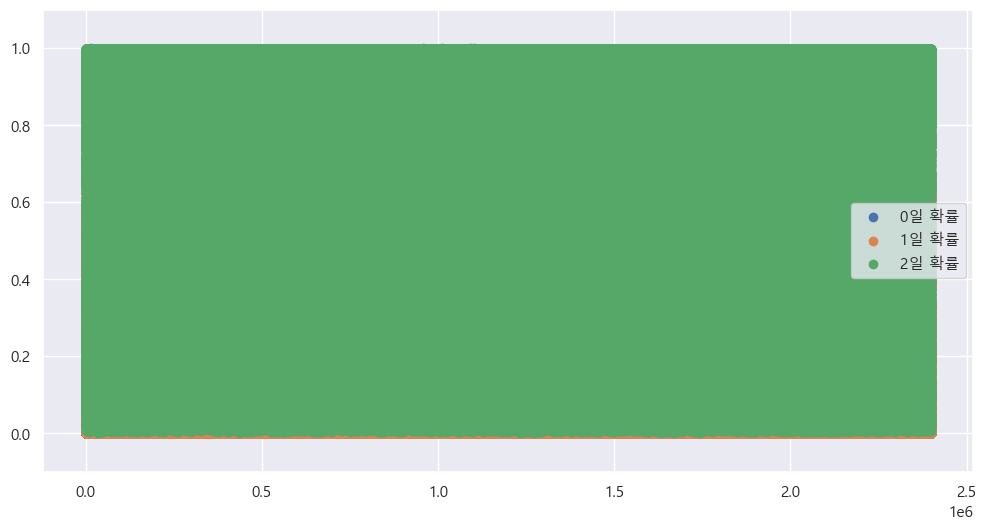


- 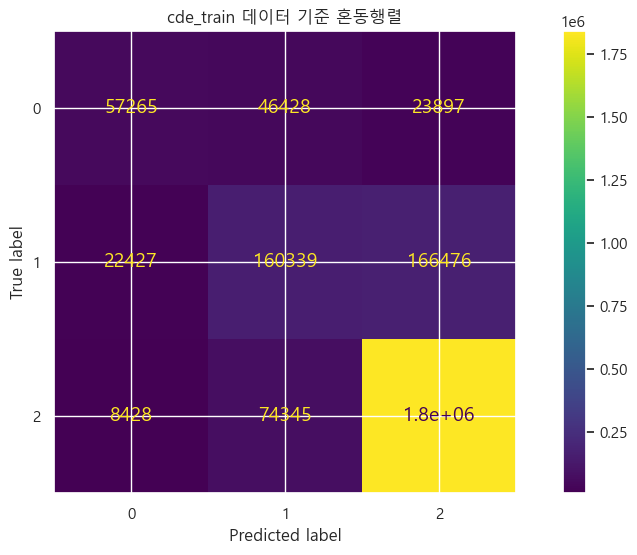


- C 클래스는 전체적으로 예측이 잘 된 편
확률 0.9 이상인 건수가 2,600건 이상이며, 애매한 구간은 상대적으로 적었음

- E 클래스는 매우 명확하게 분류됨
예측 확률 0.9 이상이 무려 144만 건 이상으로, 압도적으로 높은 신뢰도를 보였임

- 문제가 된 건 D 클래스.
확률 0.9 이상으로 명확하게 분류된 건은 442건에 불과한 반면,
0.4~0.6 사이의 애매한 확률을 가진 샘플이 무려 25만 건 이상 존재

결론
- D 클래스는 C나 E에 비해 예측 확실성이 매우 낮은 상태
특히 C-D 또는 D-E 경계에서의 모델 혼동 가능성이 높다

따라서, 후속 조치로는

- D 클래스의 추가적 이진분류 모델링,

- Feature 보완
등이 필요할 것으로 판단

f1_score: 0.8574332898130964


추가모델1 : AB-CD-E 모델 


추가모델2: C의 Feature Importance 10개 

- 선택피쳐: 
'정상청구원금_B5M', '연체입금원금_B5M', '이용금액_체크_R12M',
    '최대이용금액_일시불_R12M', '입회일자_신용', '입회경과개월수_신용',
    '카드이용한도금액_B2M', '이용후경과월_신판', '정상청구원금_B0M',
    '카드이용한도금액_B1M'

- 사용모델:
XGBoost

- 10개의 칼럼을 추가했을때 f1_score : 0.8851857780534615

- 추가했을때 오르는 모습을 보였다. 

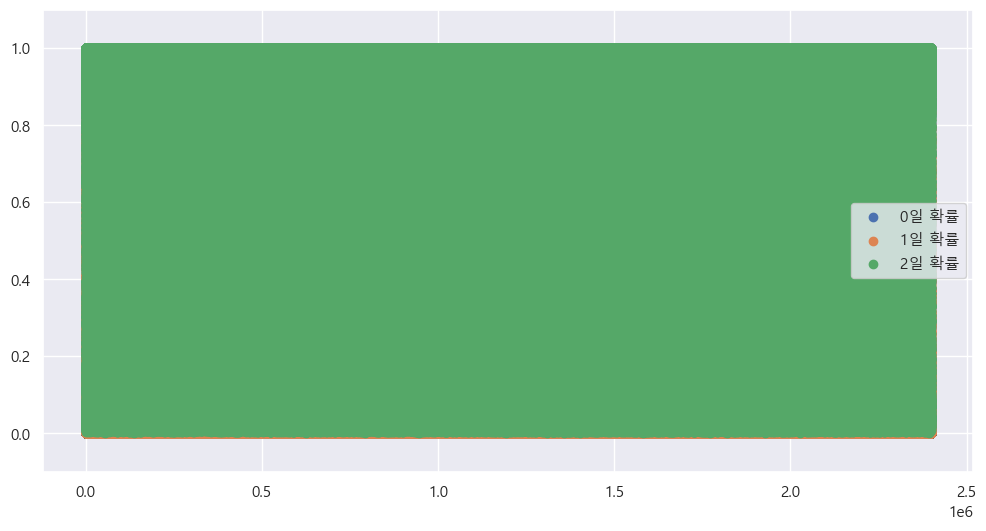

